**Feature Matrix Expansion & Column Generation**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Put the path to your downloaded Kaggle CSV file here
DATA_PATH = "/content/India_Elec_data_(Jan2020-Mar2025).csv"

print("Setup complete. Ready to load data!")

Setup complete. Ready to load data!


**Data Loading & Target Detection**

In [3]:
df = pd.read_csv(DATA_PATH, index_col='Date', parse_dates=True)

df.sort_index(inplace=True)
numeric_cols = df.select_dtypes(include=[np.number]).columns

target_col = numeric_cols[0]

print(f"Dataset successfully loaded! Shape: {df.shape}")
print(f"Target column chosen for feature engineering: '{target_col}'")
df.head(3)

Dataset successfully loaded! Shape: (69012, 8)
Target column chosen for feature engineering: 'Max Demand Met'


,State,Max Demand Met,Shortage During Peak,Energy Met,Drawl Schedule,OD(+) / UD(-),Max OD,Energy Shortage
Date,,,,,,,,
2020-01-01,Andhra Pradesh,8561.0,0.0,170.1,66.3,-0.5,367.0,0.0
2020-01-01,Arunachal Pradesh,109.0,1.0,2.2,1.9,0.2,34.0,0.0
2020-01-01,Assam,1358.0,28.0,23.4,17.3,1.3,90.0,0.2


**Cyclical Seasonal Engineering (India's Power Cycles)**

In [4]:
# Convert calendar month (1 to 12) into cyclical coordinates
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12.0)

# Convert day of the week (0 to 6) to capture weekday vs weekend industries
df['weekday_sin'] = np.sin(2 * np.pi * df.index.weekday / 7.0)
df['weekday_cos'] = np.cos(2 * np.pi * df.index.weekday / 7.0)

print("Cyclical seasonal time features engineered successfully!")

Cyclical seasonal time features engineered successfully!


In [6]:

df['lag_1d'] = df.groupby('State')[target_col].shift(1)

df['lag_7d'] = df.groupby('State')[target_col].shift(7)

df['rolling_mean_7d'] = df.groupby('State')[target_col].transform(lambda x: x.rolling(window=7).mean())

df.dropna(subset=['lag_1d', 'lag_7d', 'rolling_mean_7d'], inplace=True)

print("Lag and rolling features created successfully!")
display(df[[target_col, 'lag_1d', 'lag_7d', 'rolling_mean_7d']].head())

Lag and rolling features created successfully!


,Max Demand Met,lag_1d,lag_7d,rolling_mean_7d
Date,,,,
2020-01-08,7668.0,7842.0,8561.0,8151.428571
2020-01-08,122.0,117.0,109.0,119.714286
2020-01-08,1376.0,1382.0,1358.0,1330.142857
2020-01-08,4320.0,4483.0,4656.0,4370.285714
2020-01-08,275.0,274.0,306.0,264.428571


**Correlation Profile Matrix**

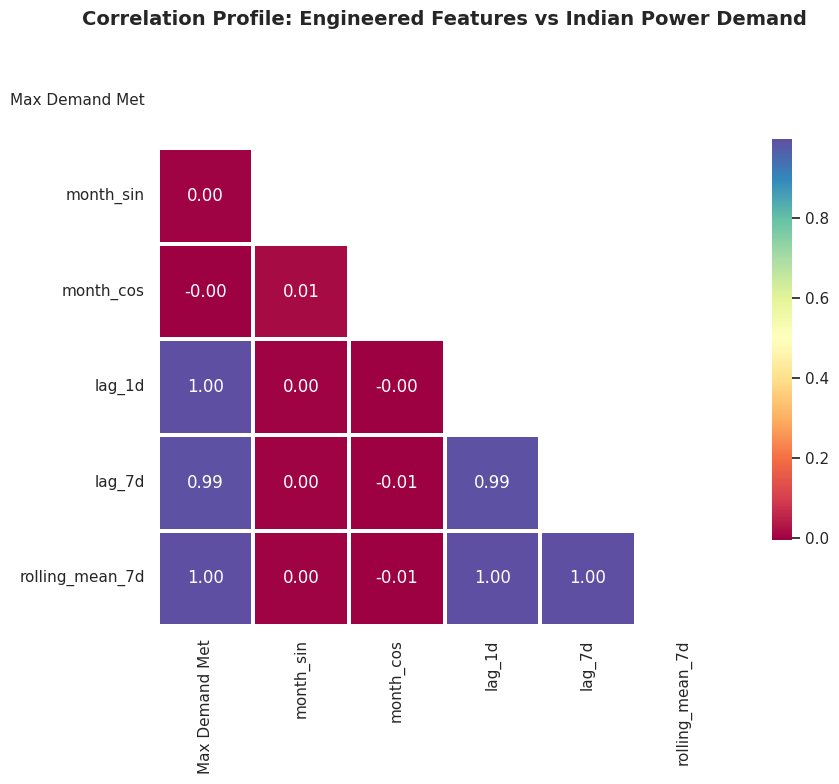

In [7]:

plt.figure(figsize=(10, 8), dpi=100)
sns.set_theme(style="white")

features_to_check = [target_col, 'month_sin', 'month_cos', 'lag_1d', 'lag_7d', 'rolling_mean_7d']

# Compute correlation matrix
corr_matrix = df[features_to_check].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    square=True,
    linewidths=1.5,
    cbar_kws={"shrink": 0.7}
)

plt.title("Correlation Profile: Engineered Features vs Indian Power Demand", fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()